# 12 — Accuracy–Latency Pareto Figure

**Chapter 4, Figure 4.2.** A publication-quality scatter of test-set accuracy
against measured Raspberry Pi 5 inference latency, with graded clinical latency
bands, the Pareto frontier marked, and dominated configurations greyed.

Notebook form of `scripts/plot_pareto.py` — the argparse flags become the
configuration cell below; everything else (palette, latency tiers, Pareto
logic, `draw_panel`) is carried over unchanged.

### Where the numbers come from

| Column | Source |
|---|---|
| `f1_nobg`, `f1_std`, `tt_sens`, `tt_sens_std`, `tt_f1` | `results/test_eval_*.md` (from `97_test_evaluation.ipynb`, median ± std over folds) |
| `latency_s` | `results/latency_pi.md` (whole-image inference, Raspberry Pi 5 CPU) |
| `params` | `docs/model_summaries.md` |

⚠️  Update `latency_s` for **2D-CNN-Fabelo** once the full repetition set
completes — the current value is from a single repetition.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Imports
# ═══════════════════════════════════════════════════════════════════════════════
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D

from brainvision.constants import CLASS_COLORS   # keep the palette in one place

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#                        CONFIGURE FIGURE HERE
# ══════════════════════════════════════════════════════════════════════════════

TWO_PANEL   = False        # add a second panel for TT sensitivity  (was --two-panel)
SHOW_LOSSES = False        # include the 1D loss variants (diamonds) (was --losses)
TOL         = 1.0          # dominance tolerance, F1 percentage points (~1 fold std error)

SAVE        = True         # also write the figure to disk
OUT         = "../figures/fig_4_2_pareto"
FORMAT      = "png"        # "png" | "pdf" | "svg"
DPI         = 300

In [3]:
# ── Palette (the project's class colours) ──────────────────────────────────
C_GREEN = CLASS_COLORS[1]      # NT — green
C_RED   = CLASS_COLORS[2]      # TT — red
C_BLUE  = CLASS_COLORS[3]      # BV — blue
C_GREY  = CLASS_COLORS[4]      # BG — grey
C_INK   = "#1E2130"            # dark ink — not a class colour

# ── Latency tiers ─────────────────────────────────────────────────────────────
# Graded thresholds refining the pre-registered 60 s constraint. Bounds are
# interaction-response conventions, not arbitrary: sub-second reads as
# continuous, a few seconds as responsive, tens of seconds as a deliberate
# action, beyond which surgical flow is broken.
TIERS = [
    ("Interactive",          0.0,   1.0,  C_GREEN, 0.13),
    ("Responsive",           1.0,   5.0,  C_GREEN, 0.07),
    ("Workflow-compatible",  5.0,  30.0,  "#E8B84B", 0.09),
    ("Disruptive",          30.0, 1e4,    C_RED,   0.09),
]

PREREGISTERED_LIMIT_S = 60.0

## Data

One row per configuration:

`label, params, latency_s, f1_nobg, f1_std, tt_sens, tt_sens_std, tt_f1, is_loss_variant`

The loss variants share the 1D-NN-Fabelo architecture (identical latency and
parameter count) and are only drawn when `SHOW_LOSSES` is set.


In [4]:
# label, params, latency_s, f1_nobg, f1_std, tt_sens, tt_sens_std, tt_f1, is_loss_variant
CONFIGS = [
    # Architecture comparison (all cross-entropy)
    ("1D-NN-Fabelo",    4_936,   0.103,  70.8, 3.2, 62.4,  9.9, 44.6, False),
    ("1D-CNN Hu",      76_824,   4.346,  73.3, 2.0, 65.1,  7.7, 55.6, False),
    ("2D-CNN-Simple",  19_644,  27.335,  71.4, 4.1, 68.3,  6.2, 43.5, False),
    ("2D-CNN-Fabelo", 142_052, 120.774,  75.9, 1.8, 66.5,  4.6, 58.0, False),

    # Loss variants on 1D-NN-Fabelo — identical architecture, identical latency.
    # Shown only with SHOW_LOSSES = True.
    ("1D-NN-Fabelo (FL)",  4_936, 0.103, 69.9, 4.2, 58.2, 12.3, 44.9, True),
    ("1D-NN-Fabelo (UFL)", 4_936, 0.103, 67.4, 3.2, 59.6,  8.7, 39.7, True),
    ("1D-NN-Fabelo (DL)",  4_936, 0.103, 61.8, 9.3, 27.4, 21.0, 20.5, True),
]

## Pareto logic

`pareto_front` returns the indices of non-dominated points over
`(latency, accuracy)` — lower latency and higher accuracy are better. `tol` is
an accuracy margin (≈ one fold standard error) so noise-level differences do
not eliminate candidates spuriously.


In [5]:
def pareto_front(points, tol=0.0):
    """
    Indices of non-dominated points. Each point is (latency, accuracy);
    lower latency and higher accuracy are better.

    `tol` is an accuracy margin: a point is only considered dominated if it is
    beaten by more than `tol`. Set this to roughly one fold standard error so
    that noise-level differences do not eliminate candidates spuriously.
    """
    keep = []
    for i, (xi, yi) in enumerate(points):
        dominated = any(
            (xj <= xi) and (yj >= yi + tol) and ((xj < xi) or (yj > yi + tol))
            for j, (xj, yj) in enumerate(points) if j != i
        )
        if not dominated:
            keep.append(i)
    return keep


def tier_of(latency):
    for name, lo, hi, _, _ in TIERS:
        if lo <= latency < hi:
            return name
    return TIERS[-1][0]

## Panel renderer

`draw_panel` is carried over from the script verbatim. It draws the latency
bands, the 60 s constraint line, the frontier over viable (< 30 s)
configurations, the points (size ∝ log parameter count, error bars = ±1 std),
and the labels; it returns the frontier indices.


In [6]:
def draw_panel(ax, rows, ycol, ystd_col, ylabel, title, tol, annotate_tt):
    lat = np.array([r[2] for r in rows])
    acc = np.array([r[ycol] for r in rows])
    std = np.array([r[ystd_col] for r in rows])
    par = np.array([r[1] for r in rows])

    # Latency bands
    xmin, xmax = 0.05, max(lat.max() * 2.2, 300)
    for name, lo, hi, colour, alpha in TIERS:
        ax.axvspan(max(lo, xmin), min(hi, xmax), color=colour,
                   alpha=alpha, zorder=0, linewidth=0)

    # Pre-registered constraint
    ax.axvline(PREREGISTERED_LIMIT_S, color=C_INK, linestyle=(0, (6, 3)),
               linewidth=1.2, zorder=2, alpha=0.65)
    _blend = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(PREREGISTERED_LIMIT_S * 0.9, 0.03, "60 s pre-registered limit",
            rotation=90, va="bottom", ha="right", fontsize=7.5,
            color=C_INK, alpha=0.8, zorder=6, transform=_blend)

    # Frontier over viable (non-disruptive) configurations only
    viable = [i for i, l in enumerate(lat) if l < 30.0]
    front_local = pareto_front([(lat[i], acc[i]) for i in viable], tol=tol)
    front = [viable[i] for i in front_local]
    front_sorted = sorted(front, key=lambda i: lat[i])

    if len(front_sorted) > 1:
        ax.plot(lat[front_sorted], acc[front_sorted], "-",
                color=C_BLUE, linewidth=1.6, alpha=0.85, zorder=3)

    # Points
    sizes = 90 + 260 * (np.log10(par) - np.log10(par.min())) / \
                  max(np.log10(par.max()) - np.log10(par.min()), 1e-9)

    for i, r in enumerate(rows):
        on_front  = i in front
        fails     = lat[i] >= PREREGISTERED_LIMIT_S
        is_loss   = r[8]

        if fails:
            face, edge, alpha = C_RED, C_RED, 0.85
        elif on_front:
            face, edge, alpha = C_BLUE, C_INK, 1.0
        else:
            face, edge, alpha = C_GREY, C_GREY, 0.55

        ax.errorbar(lat[i], acc[i], yerr=std[i], fmt="none",
                    ecolor=edge, elinewidth=1.0, capsize=3,
                    alpha=alpha * 0.6, zorder=4)
        ax.scatter(lat[i], acc[i], s=sizes[i], c=face, edgecolors=edge,
                   linewidths=1.4, zorder=5, alpha=alpha,
                   marker="D" if is_loss else "o")

        # Labels
        label = r[0]
        if annotate_tt and not is_loss:
            label += f"\nTT sens {r[5]:.1f}%"
        offset_y = 11 if i % 2 == 0 else -26
        ax.annotate(label, (lat[i], acc[i]),
                    textcoords="offset points", xytext=(0, offset_y),
                    ha="center", fontsize=7.5,
                    color=C_INK if not fails else C_RED,
                    fontweight="bold" if on_front else "normal", zorder=6)

    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Inference latency per image, Raspberry Pi 5 (s, log scale)",
                  fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, pad=10)
    ax.grid(alpha=0.18, linewidth=0.6)
    ax.tick_params(labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("#CCCCCC")

    return front

## Build the figure


Figure → ../figures/fig_4_2_pareto.png


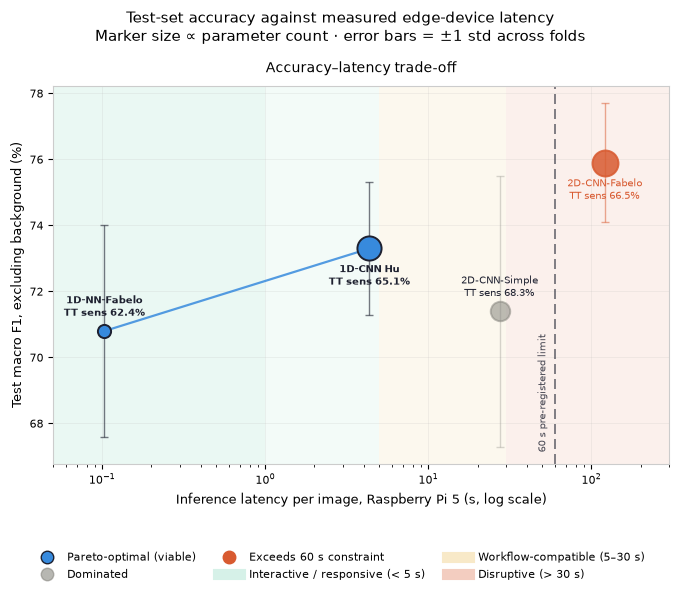

In [7]:
rows = [r for r in CONFIGS if SHOW_LOSSES or not r[8]]

n_panels = 2 if TWO_PANEL else 1
fig, axes = plt.subplots(1, n_panels, figsize=(7.0 * n_panels, 5.9))
axes = np.atleast_1d(axes)

front = draw_panel(
    axes[0], rows, ycol=3, ystd_col=4,
    ylabel="Test macro F1, excluding background (%)",
    title="Accuracy–latency trade-off",
    tol=TOL, annotate_tt=not TWO_PANEL,
)

if TWO_PANEL:
    draw_panel(
        axes[1], rows, ycol=5, ystd_col=6,
        ylabel="Tumour tissue sensitivity (%)",
        title="Clinical priority metric",
        tol=TOL, annotate_tt=False,
    )

# Legend
handles = [
    Line2D([], [], marker="o", linestyle="", markersize=9,
           markerfacecolor=C_BLUE, markeredgecolor=C_INK,
           label="Pareto-optimal (viable)"),
    Line2D([], [], marker="o", linestyle="", markersize=9,
           markerfacecolor=C_GREY, markeredgecolor=C_GREY, alpha=0.6,
           label="Dominated"),
    Line2D([], [], marker="o", linestyle="", markersize=9,
           markerfacecolor=C_RED, markeredgecolor=C_RED,
           label="Exceeds 60 s constraint"),
]
if SHOW_LOSSES:
    handles.append(
        Line2D([], [], marker="D", linestyle="", markersize=8,
               markerfacecolor=C_GREY, markeredgecolor=C_GREY,
               label="Loss variant (same architecture)")
    )
handles += [
    Line2D([], [], color=C_GREEN, linewidth=8, alpha=0.25,
           label="Interactive / responsive (< 5 s)"),
    Line2D([], [], color="#E8B84B", linewidth=8, alpha=0.3,
           label="Workflow-compatible (5–30 s)"),
    Line2D([], [], color=C_RED, linewidth=8, alpha=0.3,
           label="Disruptive (> 30 s)"),
]
fig.legend(handles=handles, loc="lower center",
           ncol=3 if n_panels == 1 else 4,
           fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.005))

fig.suptitle(
    "Test-set accuracy against measured edge-device latency\n"
    "Marker size ∝ parameter count · error bars = ±1 std across folds",
    fontsize=11,
)
fig.subplots_adjust(top=0.85, bottom=0.21, left=0.09,
                    right=0.97, wspace=0.22)

if SAVE:
    out_path = Path(f"{OUT}.{FORMAT}")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=DPI, facecolor="white", bbox_inches="tight")
    print(f"Figure → {out_path}")

plt.show()

## Viable-region analysis

Console summary of the selection: which configurations are Pareto-optimal,
which are dominated, and which are excluded for exceeding the 60 s constraint.


In [8]:
print("Viable-region analysis "
      f"(dominance tolerance {TOL:.1f} pp):\n")
print(f"  {'Configuration':<22}{'Latency':>10}  {'Tier':<22}"
      f"{'F1-noBG':>9}{'TT sens':>9}  Verdict")
print("  " + "-" * 88)
for i, r in enumerate(rows):
    if r[8]:
        continue
    if r[2] >= PREREGISTERED_LIMIT_S:
        verdict = "EXCLUDED — exceeds constraint"
    elif i in front:
        verdict = "PARETO-OPTIMAL"
    else:
        verdict = "dominated"
    print(f"  {r[0]:<22}{r[2]:>9.2f}s  {tier_of(r[2]):<22}"
          f"{r[3]:>8.1f}%{r[5]:>8.1f}%  {verdict}")

print("\n  Recommended configuration: the Pareto-optimal point with the "
      "highest\n  accuracy inside the responsive (< 5 s) tier.")

Viable-region analysis (dominance tolerance 1.0 pp):

  Configuration            Latency  Tier                    F1-noBG  TT sens  Verdict
  ----------------------------------------------------------------------------------------
  1D-NN-Fabelo               0.10s  Interactive               70.8%    62.4%  PARETO-OPTIMAL
  1D-CNN Hu                  4.35s  Responsive                73.3%    65.1%  PARETO-OPTIMAL
  2D-CNN-Simple             27.34s  Workflow-compatible       71.4%    68.3%  dominated
  2D-CNN-Fabelo            120.77s  Disruptive                75.9%    66.5%  EXCLUDED — exceeds constraint

  Recommended configuration: the Pareto-optimal point with the highest
  accuracy inside the responsive (< 5 s) tier.
